## **AMR Interpolation**

Import relevant libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

#### Useful functions

In [2]:
def process_data(input_dir):
    
    all_data = []
    
    for n in range(74, 517):
        
        filename = input_dir + str(n) + ".raw"
        data = np.empty((256, 96, 96))
        
        with open(filename, "rb") as file:
            for k in range(96):
                for j in range(96):
                    for i in range(256):
                        data[i, j, k] = struct.unpack('<f', file.read(4))[0]
        all_data.append(data)
        print("Processed data from file ", n, "!")

    return all_data

def check_one_out(data, i, j, k):
    times = torch.linspace(0, 1, len(data))
    measurements = torch.empty((len(data)))
    for t in range(len(data)):
        measurements[t] = data[t][i, j, k] / 1e9
    plt.figure(figsize=(15, 5))
    plt.plot(times, measurements, '.', markersize=10)
    return times, measurements

#### Data reading/formatting

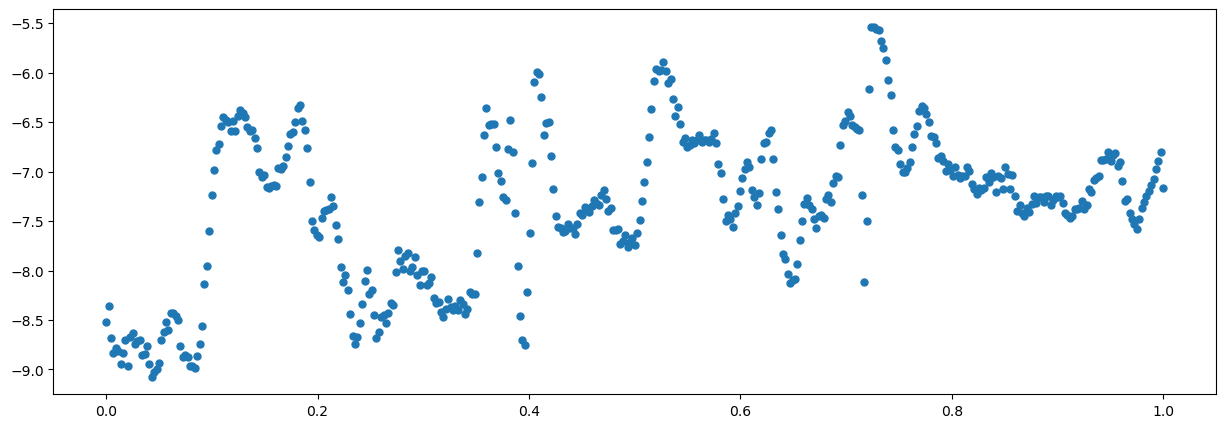

In [50]:
# times = torch.linspace(0, 1, 1000)
# temps = 1000 + 100*np.sin(times*30)
# noise = torch.empty(1000).uniform_(-50, 50)
# temps = temps + noise
# plt.figure(figsize=(15,5))
# plt.plot(times, temps, '.', markersize=10, label='temp over time')
# input_times = times.view(-1,1)
# input_temps = temps.view(-1,1)
    
# data = process_data("volumes/")
times, measurements = check_one_out(data, 50, 63, 44)
input_times = times.view(-1,1)
input_measurements = measurements.view(-1,1)

#### Define Model

In [51]:
class RegressionModel(nn.Module):
    def __init__(self):
        super(RegressionModel, self).__init__()
        self.poly = nn.Sequential(
            nn.Linear(1, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            # nn.Linear(1024, 2048),
            # nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            # nn.Linear(2048, 1024),
            # nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.poly(x)

#### Hyperparameters

In [52]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
lr = 3e-4
num_epochs = 10000

Running on cuda


#### Initializations

In [53]:
model = RegressionModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

#### Train, test functions

In [54]:
def train(model, X_tensor, y_tensor, criterion, optimizer, epochs):
    
    loss_hist = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # forward pass
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss_hist.append(loss.item())

        # backward pass and optimization
        loss.backward()
        optimizer.step()

        if (epoch+1) % 500 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

    return loss_hist

#### Learn model

In [56]:
loss_hist = train(model, input_times, input_measurements, criterion, optimizer, num_epochs)

Epoch [500/10000], Loss: 0.1070
Epoch [1000/10000], Loss: 0.1081
Epoch [1500/10000], Loss: 0.1021
Epoch [2000/10000], Loss: 0.1195
Epoch [2500/10000], Loss: 0.1068
Epoch [3000/10000], Loss: 0.1031
Epoch [3500/10000], Loss: 0.1069
Epoch [4000/10000], Loss: 0.0921
Epoch [4500/10000], Loss: 0.0898
Epoch [5000/10000], Loss: 0.0935
Epoch [5500/10000], Loss: 0.0946
Epoch [6000/10000], Loss: 0.0836
Epoch [6500/10000], Loss: 0.0887
Epoch [7000/10000], Loss: 0.0813
Epoch [7500/10000], Loss: 0.1181
Epoch [8000/10000], Loss: 0.0838
Epoch [8500/10000], Loss: 0.0920
Epoch [9000/10000], Loss: 0.0825
Epoch [9500/10000], Loss: 0.0917
Epoch [10000/10000], Loss: 0.0736


#### Plot results

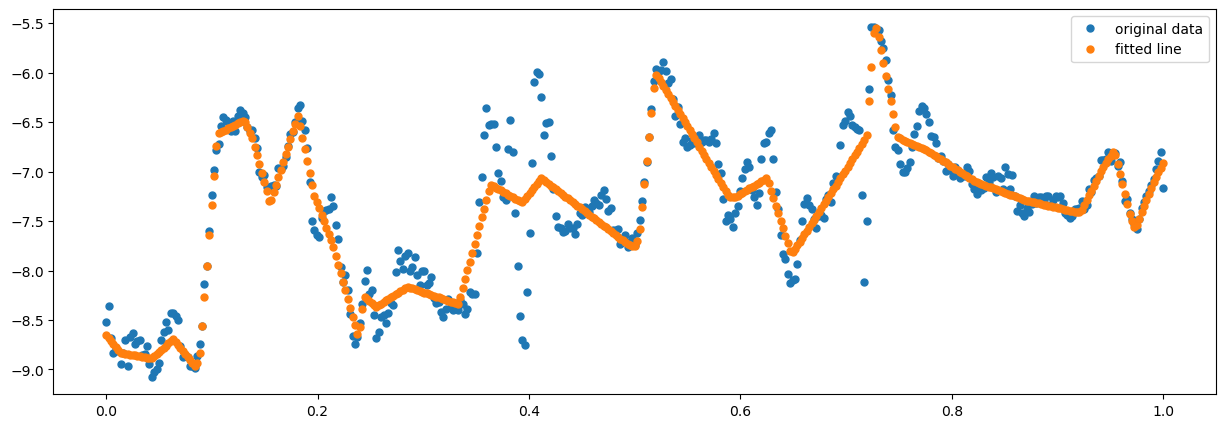

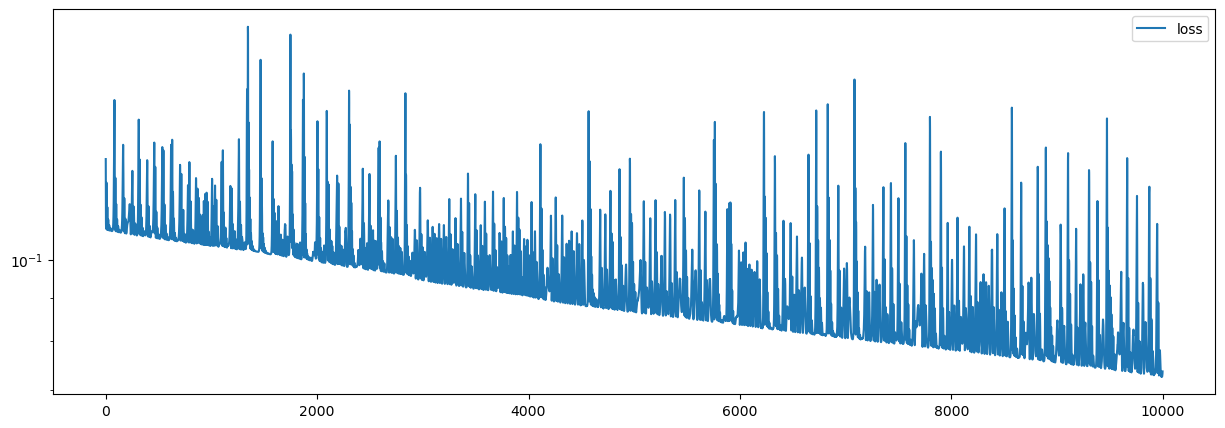

In [57]:
model.eval()
with torch.no_grad():
    predicted = model(input_times).numpy()

plt.figure(figsize = (15,5))
plt.plot(times, measurements, '.', markersize=10, label='original data')
plt.plot(times, predicted, '.', markersize=10, label='fitted line')
plt.legend()

plt.figure(figsize = (15,5))
plt.yscale('log')
plt.plot(range(num_epochs), loss_hist, label='loss')
plt.legend()